In [9]:
import json

with open("pix3d/pix3d.json", "r") as f:
    pix3d_data = json.load(f)

print("Total samples:", len(pix3d_data))
print(pix3d_data[0])

Total samples: 10069
{'img': 'img/bed/0001.png', 'category': 'bed', 'img_size': [395, 244], '2d_keypoints': [[[182.5, 147.09375], [174.5, 225.09375], [16.5, 111.09375], [-1.0, -1.0], [-1.0, -1.0], [324.5, 101.09375], [336.5, 51.09375], [226.5, 20.09375], [-1.0, -1.0], [352.5, 121.09375]], [[181.5, 165.09375], [181.5, 224.09375], [3.5, 112.09375], [5.5, 141.09375], [-1.0, -1.0], [352.5, 90.09375], [349.5, 34.09375], [196.5, 26.09375], [-1.0, -1.0], [346.5, 114.09375]], [[171.5, 139.09375], [175.5, 227.09375], [29.5, 90.09375], [-1.0, -1.0], [-1.0, -1.0], [340.5, 80.09375], [351.5, 32.09375], [198.5, 22.09375], [-1.0, -1.0], [268.5, 79.09375]]], 'mask': 'mask/bed/0001.png', 'img_source': 'ikea', 'model': 'model/bed/IKEA_MALM_2/model.obj', 'model_raw': None, 'model_source': 'ikea', '3d_keypoints': 'model/bed/IKEA_MALM_2/3d_keypoints.txt', 'voxel': 'model/bed/IKEA_MALM_2/voxel.mat', 'rot_mat': [[0.7813941591465821, 0.00095539348511137, -0.6240370624208909], [0.17456672296585038, 0.95974077

(np.float64(-0.5), np.float64(394.5), np.float64(243.5), np.float64(-0.5))

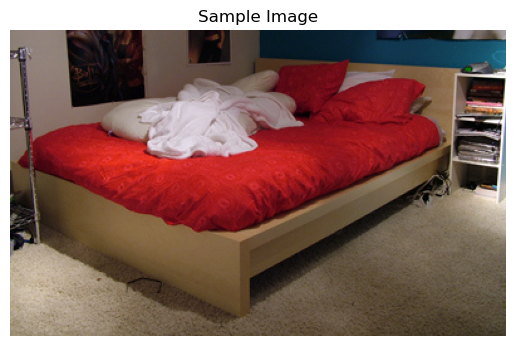

In [10]:
import cv2
import matplotlib.pyplot as plt

sample = pix3d_data[0]

img_path = "pix3d/" + sample["img"]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Image")
plt.axis("off")

(np.float64(-0.5), np.float64(394.5), np.float64(243.5), np.float64(-0.5))

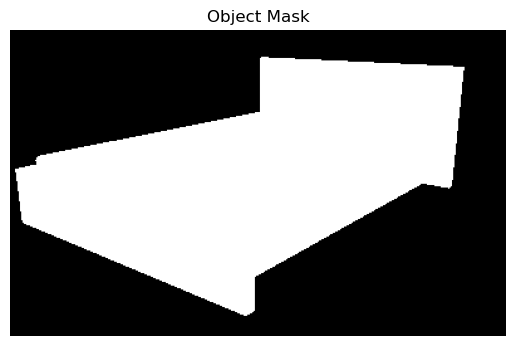

In [11]:
mask_path = "pix3d/" + sample["mask"]

mask = cv2.imread(mask_path, 0)

plt.imshow(mask, cmap="gray")
plt.title("Object Mask")
plt.axis("off")

In [12]:
import open3d as o3d

model_path = "pix3d/" + sample["model"]

mesh = o3d.io.read_triangle_mesh(model_path)

o3d.visualization.draw_geometries([mesh])

In [13]:
pcd = mesh.sample_points_uniformly(number_of_points=5000)

o3d.visualization.draw_geometries([pcd])

In [14]:
from torch.utils.data import Dataset
import torch
import cv2
import open3d as o3d
import numpy as np

class Pix3DDataset(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        sample = self.data[idx]

        # IMAGE
        img_path = "pix3d/" + sample["img"]
        img = cv2.imread(img_path)
        img = cv2.resize(img,(224,224))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = torch.tensor(img).permute(2,0,1).float()/255

        # 3D MODEL
        model_path = "pix3d/" + sample["model"]

        mesh = o3d.io.read_triangle_mesh(model_path)

        pcd = mesh.sample_points_uniformly(number_of_points=1024)

        points = np.asarray(pcd.points)

        points = torch.tensor(points).float()

        return img, points

In [15]:
dataset = Pix3DDataset(pix3d_data)

print("Dataset size:", len(dataset))

Dataset size: 10069


In [16]:
img, points = dataset[0]

print(img.shape)
print(points.shape)

torch.Size([3, 224, 224])
torch.Size([1024, 3])


In [17]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

In [18]:
for img, points in dataloader:
    print(img.shape)
    print(points.shape)
    break

torch.Size([8, 3, 224, 224])
torch.Size([8, 1024, 3])


In [19]:
import torch.nn as nn

class ImageEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3,32,4,2,1),
            nn.ReLU(),

            nn.Conv2d(32,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,4,2,1),
            nn.ReLU(),

            nn.Conv2d(128,256,4,2,1),
            nn.ReLU(),

            nn.Flatten(),
            nn.Linear(256*14*14,1024)
        )

    def forward(self,x):

        x = self.encoder(x)
        return x

In [20]:
class PointDecoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.decoder = nn.Sequential(
            nn.Linear(1024,2048),
            nn.ReLU(),
            nn.Linear(2048,1024*3)
        )

    def forward(self,x):

        x = self.decoder(x)

        x = x.view(-1,1024,3)

        return x

In [21]:
class ReconstructionModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = ImageEncoder()
        self.decoder = PointDecoder()

    def forward(self,x):

        x = self.encoder(x)

        points = self.decoder(x)

        return points

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ReconstructionModel().to(device)

print(device)

cuda


In [23]:
loss_fn = nn.MSELoss()

In [24]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [21]:
for epoch in range(5):

    for img, points in dataloader:

        img = img.to(device)
        points = points.to(device)

        pred = model(img)

        loss = loss_fn(pred, points)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    print("Epoch:",epoch,"Loss:",loss.item())

[Open3D WARNING] Read geometry::Image failed for file pix3d\model\desk\IKEA_LEKSVIK\e4265ddbf415ef1877fe0205d04e5011_obj0_object/wenge.bmp. Unknown file signature, only PNG and JPG are supported.
[Open3D WARNING] Read geometry::Image failed for file pix3d\model\desk\IKEA_LEKSVIK\e4265ddbf415ef1877fe0205d04e5011_obj0_object/wenge.bmp. Unknown file signature, only PNG and JPG are supported.
[Open3D WARNING] Read geometry::Image failed for file pix3d\model\desk\IKEA_LEKSVIK\e4265ddbf415ef1877fe0205d04e5011_obj0_object/wenge.bmp. Unknown file signature, only PNG and JPG are supported.
[Open3D WARNING] Read geometry::Image failed for file pix3d\model\desk\IKEA_LEKSVIK\e4265ddbf415ef1877fe0205d04e5011_obj0_object/wenge.bmp. Unknown file signature, only PNG and JPG are supported.
[Open3D WARNING] Read geometry::Image failed for file pix3d\model\desk\IKEA_LEKSVIK\e4265ddbf415ef1877fe0205d04e5011_obj0_object/wenge.bmp. Unknown file signature, only PNG and JPG are supported.
[Open3D WARNING] Rea

In [22]:
torch.save(model.state_dict(), "pix3d_reconstruction_model.pth")

In [25]:
model = ReconstructionModel().to(device)

model.load_state_dict(torch.load("pix3d_reconstruction_model.pth"))

model.eval()

C:\Users\HP\AppData\Local\Temp\ipykernel_744\1030834444.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("pix3d_reconstruction_model.pth"

ReconstructionModel(
  (encoder): ImageEncoder(
    (encoder): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=50176, out_features=1024, bias=True)
    )
  )
  (decoder): PointDecoder(
    (decoder): Sequential(
      (0): Linear(in_features=1024, out_features=2048, bias=True)
      (1): ReLU()
      (2): Linear(in_features=2048, out_features=3072, bias=True)
    )
  )
)

In [26]:
model.eval()

ReconstructionModel(
  (encoder): ImageEncoder(
    (encoder): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=50176, out_features=1024, bias=True)
    )
  )
  (decoder): PointDecoder(
    (decoder): Sequential(
      (0): Linear(in_features=1024, out_features=2048, bias=True)
      (1): ReLU()
      (2): Linear(in_features=2048, out_features=3072, bias=True)
    )
  )
)

In [27]:
test_img, gt_points = dataset[10]

In [28]:
test_img = test_img.unsqueeze(0).to(device)

In [29]:
with torch.no_grad():
    predicted_points = model(test_img)

In [30]:
predicted_points = predicted_points.cpu().numpy()[0]

In [33]:
import open3d as o3d

pcd_pred = o3d.geometry.PointCloud()

pcd_pred.points = o3d.utility.Vector3dVector(predicted_points)

o3d.visualization.draw_geometries([pcd_pred])

In [32]:
gt_points = gt_points.numpy()

pcd_gt = o3d.geometry.PointCloud()

pcd_gt.points = o3d.utility.Vector3dVector(gt_points)

o3d.visualization.draw_geometries([pcd_gt])

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

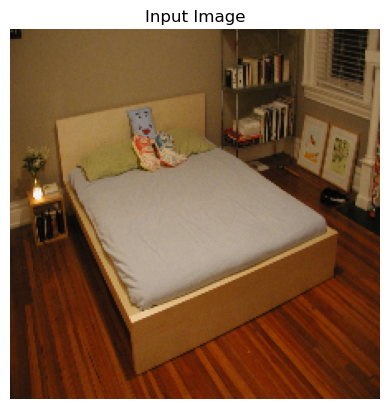

In [34]:
import matplotlib.pyplot as plt

img_show = test_img.cpu().squeeze().permute(1,2,0)

plt.imshow(img_show)
plt.title("Input Image")
plt.axis("off")

In [35]:
for i in range(5):

    img, gt = dataset[i]

    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img)

    pred = pred.cpu().numpy()[0]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pred)

    o3d.visualization.draw_geometries([pcd])

In [38]:
import torch
import torch.nn.functional as F

pred = torch.tensor(predicted_points).float()
gt = torch.tensor(gt_points).float()

print("Pred shape:", pred.shape)
print("GT shape:", gt.shape)

loss = F.mse_loss(pred, gt)

print("Test Loss:", loss.item())

Pred shape: torch.Size([1024, 3])
GT shape: torch.Size([1024, 3])
Test Loss: 0.03758060559630394
